# CAR PRICE PREDICTION PROJECT 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df=pd.read_csv('car.csv')
df.head(5)

,name,year,km_driven,fuel,seller_type,transmission,owner,selling_price
0,Maruti 800 AC,2007,70000,Petrol,Individual,Manual,First Owner,60000
1,Maruti Wagon R LXI Minor,2007,50000,Petrol,Individual,Manual,First Owner,135000
2,Hyundai Verna 1.6 SX,2012,100000,Diesel,Individual,Manual,First Owner,600000
3,Datsun RediGO T Option,2017,46000,Petrol,Individual,Manual,First Owner,250000
4,Honda Amaze VX i-DTEC,2014,141000,Diesel,Individual,Manual,Second Owner,450000


In [4]:
df.isnull().sum()

name             0
year             0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
selling_price    0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   km_driven      4340 non-null   int64
 3   fuel           4340 non-null   str  
 4   seller_type    4340 non-null   str  
 5   transmission   4340 non-null   str  
 6   owner          4340 non-null   str  
 7   selling_price  4340 non-null   int64
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [6]:
df['company'] = df['name'].apply(lambda x: x.split()[0])

# Convert categorical columns into numbers
df = pd.get_dummies(df,
                    columns=['fuel',
                             'seller_type',
                             'transmission',
                             'owner',
                             'company'],
                    drop_first=True,
                    dtype=int)

# Remove original name column
df.drop('name', axis=1, inplace=True)

# Check dataframe
print(df.head())

   year  km_driven  selling_price  fuel_Diesel  fuel_Electric  fuel_LPG  \
0  2007      70000          60000            0              0         0   
1  2007      50000         135000            0              0         0   
2  2012     100000         600000            1              0         0   
3  2017      46000         250000            0              0         0   
4  2014     141000         450000            1              0         0   

   fuel_Petrol  seller_type_Individual  seller_type_Trustmark Dealer  \
0            1                       1                             0   
1            1                       1                             0   
2            0                       1                             0   
3            1                       1                             0   
4            0                       1                             0   

   transmission_Manual  ...  company_Mercedes-Benz  company_Mitsubishi  \
0                    1  ...               

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 42 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   year                          4340 non-null   int64
 1   km_driven                     4340 non-null   int64
 2   selling_price                 4340 non-null   int64
 3   fuel_Diesel                   4340 non-null   int64
 4   fuel_Electric                 4340 non-null   int64
 5   fuel_LPG                      4340 non-null   int64
 6   fuel_Petrol                   4340 non-null   int64
 7   seller_type_Individual        4340 non-null   int64
 8   seller_type_Trustmark Dealer  4340 non-null   int64
 9   transmission_Manual           4340 non-null   int64
 10  owner_Fourth & Above Owner    4340 non-null   int64
 11  owner_Second Owner            4340 non-null   int64
 12  owner_Test Drive Car          4340 non-null   int64
 13  owner_Third Owner             4340 non-null 

In [8]:
x = df.drop('selling_price', axis=1)
y = df['selling_price']

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling
ss = StandardScaler()

x_train = ss.fit_transform(x_train)
x_test = ss.transform(x_test)

In [10]:
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [11]:
lr=LinearRegression()
lr.fit(x_train,y_train)
lr.score(x_train,y_train)*100 , lr.score(x_test,y_test)*100 


#mean_squared_error(y_test,lr.predict(x_test)) , mean_absolute_error(y_test,lr.predict(x_test))

(72.11653365756457, 52.990371751304544)

In [12]:
lr1=Lasso(alpha=0.1)
lr1.fit(x_train,y_train)
lr1.score(x_train,y_train)*100 , lr1.score(x_test,y_test)*100 

mean_squared_error(y_test,lr1.predict(x_test)) , mean_absolute_error(y_test,lr1.predict(x_test))

C:\Users\SAMRUDHI\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.505e+14, tolerance: 1.187e+11
  model = cd_fast.enet_coordinate_descent(


(143458312498.86523, 184879.5844616248)

In [13]:
dt=DecisionTreeRegressor(max_depth=10,random_state=42)
dt.fit(x_train,y_train)
dt.score(x_train,y_train)*100 , dt.score(x_test,y_test)*100 

mean_squared_error(y_test,dt.predict(x_test)) , mean_absolute_error(y_test,dt.predict(x_test))

(106714288961.0496, 139506.7871143119)

In [14]:
rm=RandomForestRegressor(n_estimators=100,max_depth=10,random_state=42)
rm.fit(x_train,y_train)
rm.score(x_train,y_train)*100 , rm.score(x_test,y_test)*100 

mean_squared_error(y_test,rm.predict(x_test)) , mean_absolute_error(y_test,rm.predict(x_test))

(81255901346.18488, 125403.83085466104)

In [15]:
kn=KNeighborsRegressor(n_neighbors=5)
kn.fit(x_train,y_train)
kn.score(x_train,y_train)*100 , kn.score(x_test,y_test)*100 

mean_squared_error(y_test,kn.predict(x_test)) , mean_absolute_error(y_test,kn.predict(x_test))

(102653265230.10866, 136877.44792626728)

In [ ]:
model_names = [
    'Linear Regression',
    'Lasso',
    'Decision Tree',
    'Random Forest',
    'KNN'
]


In [23]:
scores = [
    lr.score(x_test,y_test)*100,
    lr1.score(x_test,y_test)*100,
    dt.score(x_test,y_test)*100,
    rm.score(x_test,y_test)*100,
    kn.score(x_test,y_test)*100
]

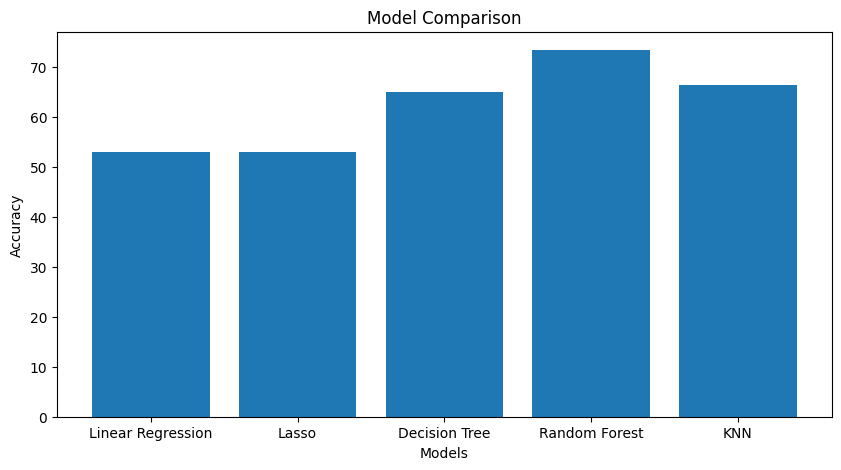

In [26]:
plt.figure(figsize=(10,5))
plt.bar(model_names, scores)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.show()